# Latent Masked Linear Backbone Plus Residual Overview

This notebook studies the hybrid model where a linear latent backbone is combined with an active residual correction path.

The setup mirrors the simple identity attention notebook, but switches on a linear backbone through `residual_mode="linear_residual"`.


In [12]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import main
import models.config
import models.eval
import models.lightning_module
import models.loss
import models.latent_attn_masked

importlib.reload(models.loss)
importlib.reload(models.lightning_module)
importlib.reload(models.latent_attn_masked)
importlib.reload(models.eval)
importlib.reload(models.config)
importlib.reload(main)

from main import Sim
from models.config import build_model
from models.loss import get_model_input, train_model

RESULTS_ROOT = Path('results/local_results')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


In [13]:
config_override = {
    "model": {
        "n_components_pca": 512,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 32,
        "attn_dim": 64,
        "value_dim": 64,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 64,
        "residual_mode": "linear_residual",
        "residual_gain_init": 1.0e-3,
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 1e-5,
    },
    "trainer": {
        "max_epochs": 200,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

sim = Sim(
    model_name="LatentAttnMasked",
    config_overrides=config_override,
    source="SC",
    target="FC",
    parcellation="Glasser",
    shuffle_seed=0,
    data_load_mode="precomputed",
)


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


LatentAttnMasked init | src=SC tgt=FC | k=256 pls=64 | token_embedding_type=learned token_embedding_dim=32 | residual_mode=linear_residual residual_gain_init=0.001 | attn_dim=64 value_dim=64 | transformer_layers=0 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=64 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 86.4 K | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
---------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


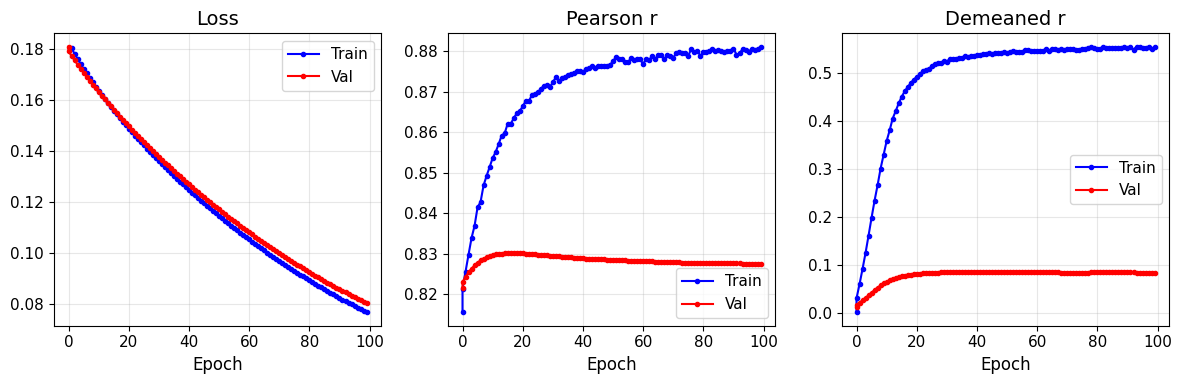

Number of unique demographic categories: 14
Top-1 accuracy: 0.046  (9 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.759 (chance=0.5)


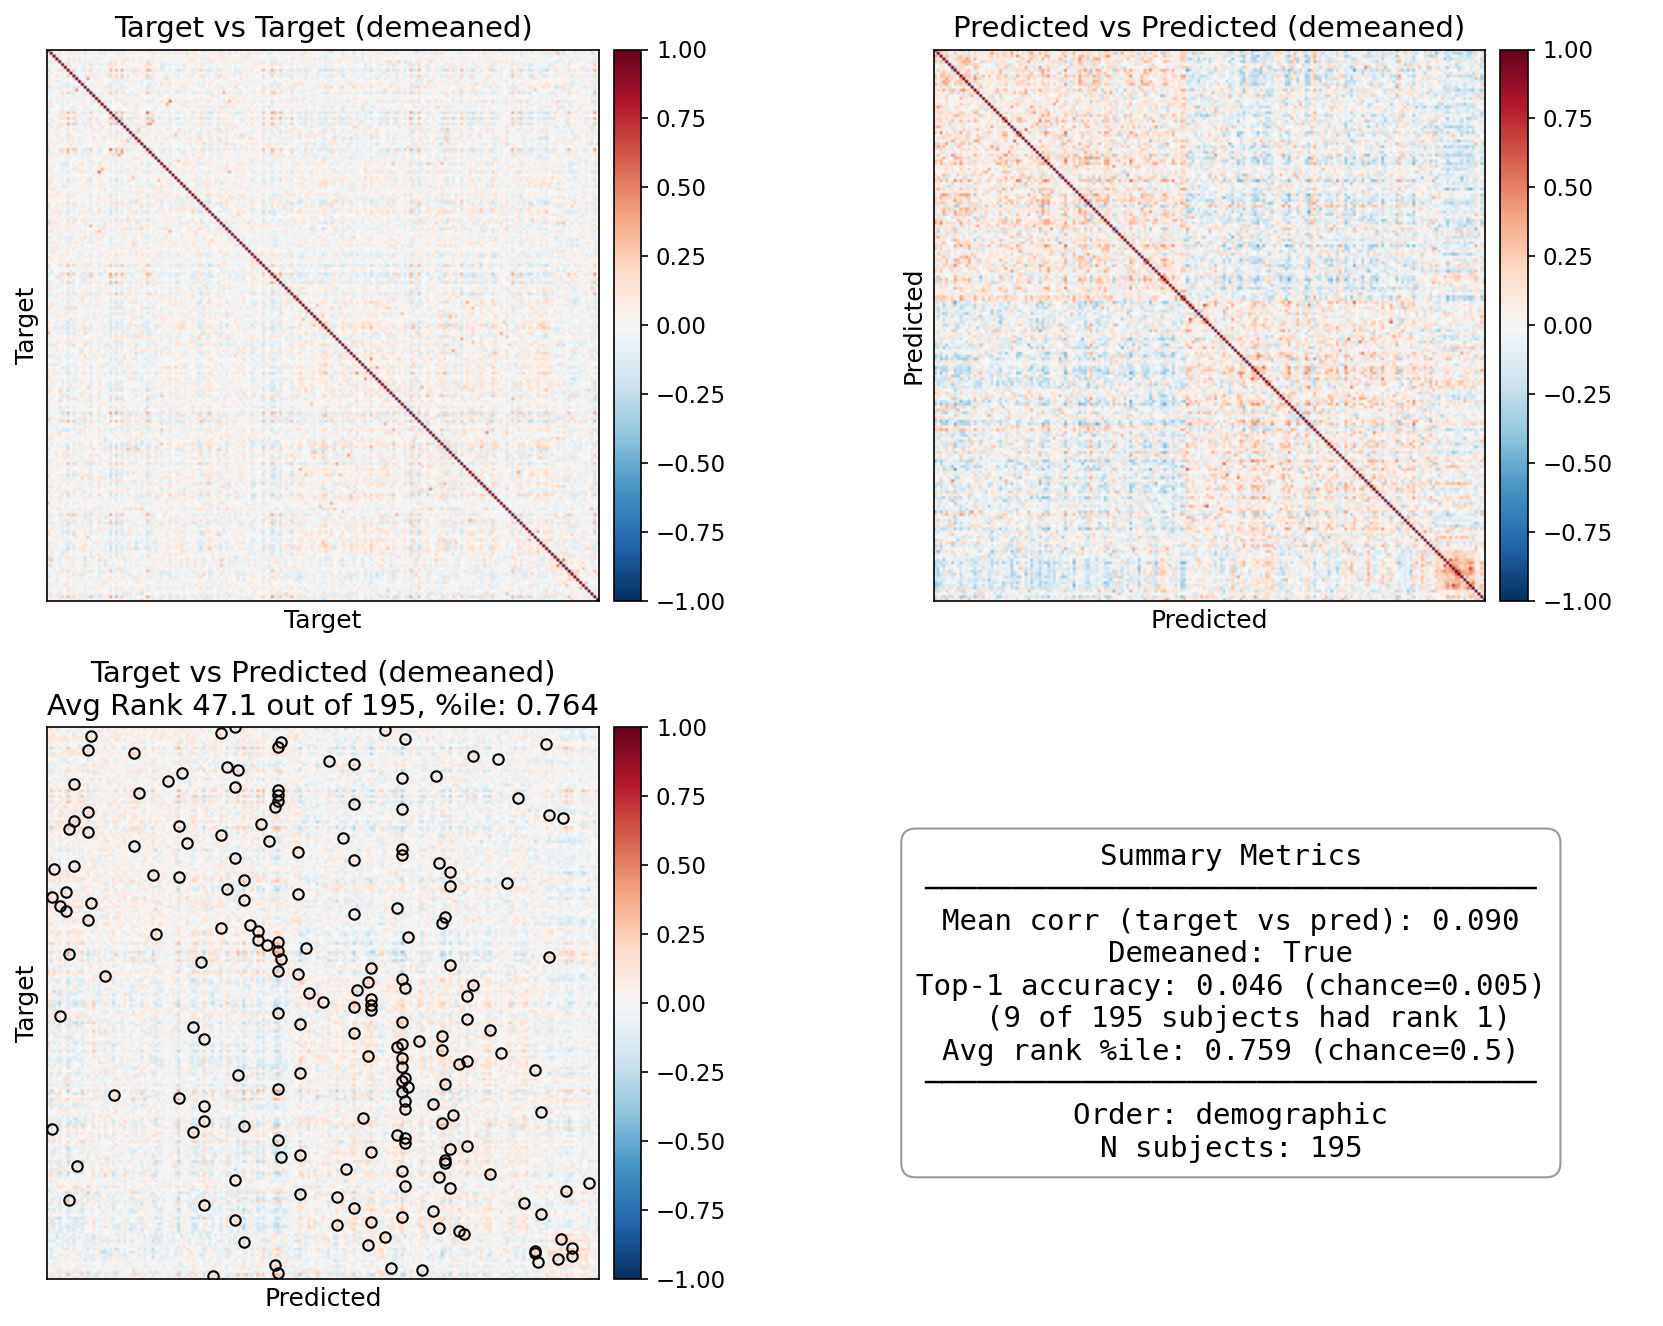

returned noise_preds [[ 0.10335521  0.27345122  0.79338547 ...  0.07845211  0.10779614
   0.35724186]
 [ 0.1919979   0.47149277  0.6724819  ... -0.13729251 -0.09331813
   0.66529665]
 [ 0.3631451   0.63926478  0.88444692 ... -0.01370378  0.1294217
   0.39960487]
 ...
 [-0.08238107  0.82869741  1.07752772 ... -0.06908563 -0.00440757
   0.40327927]
 [ 0.12395491  0.68586381  0.6269891  ... -0.12566293  0.16673286
   0.53747594]
 [ 0.05569953  0.62698837  0.69579952 ... -0.09271121  0.09947315
   0.36341394]]


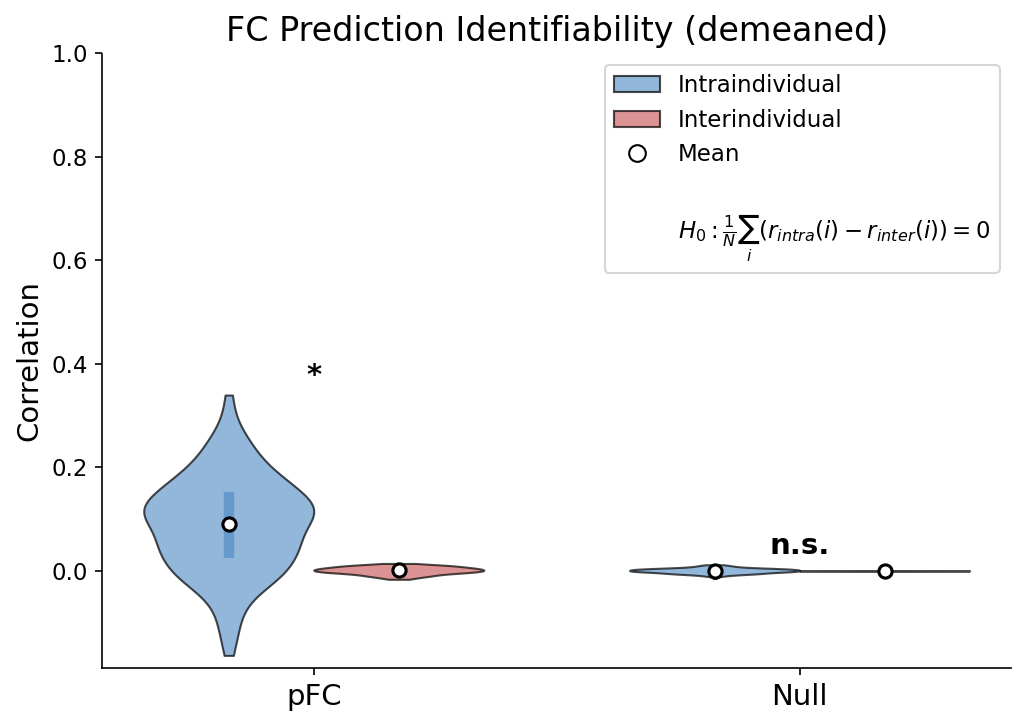


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          0.0899     0.0008     0.0891     13.19      8.71e-29     0.94      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


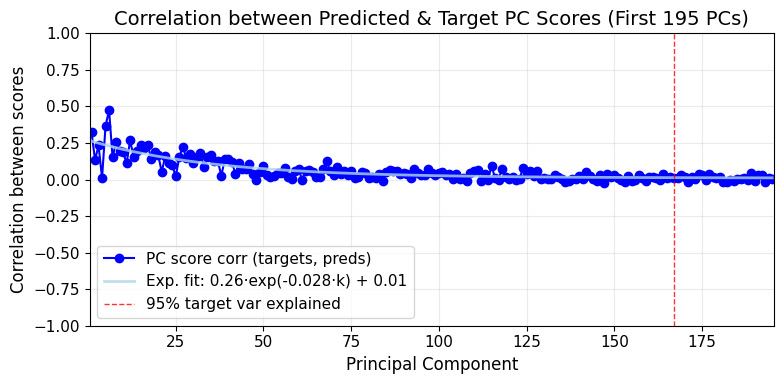

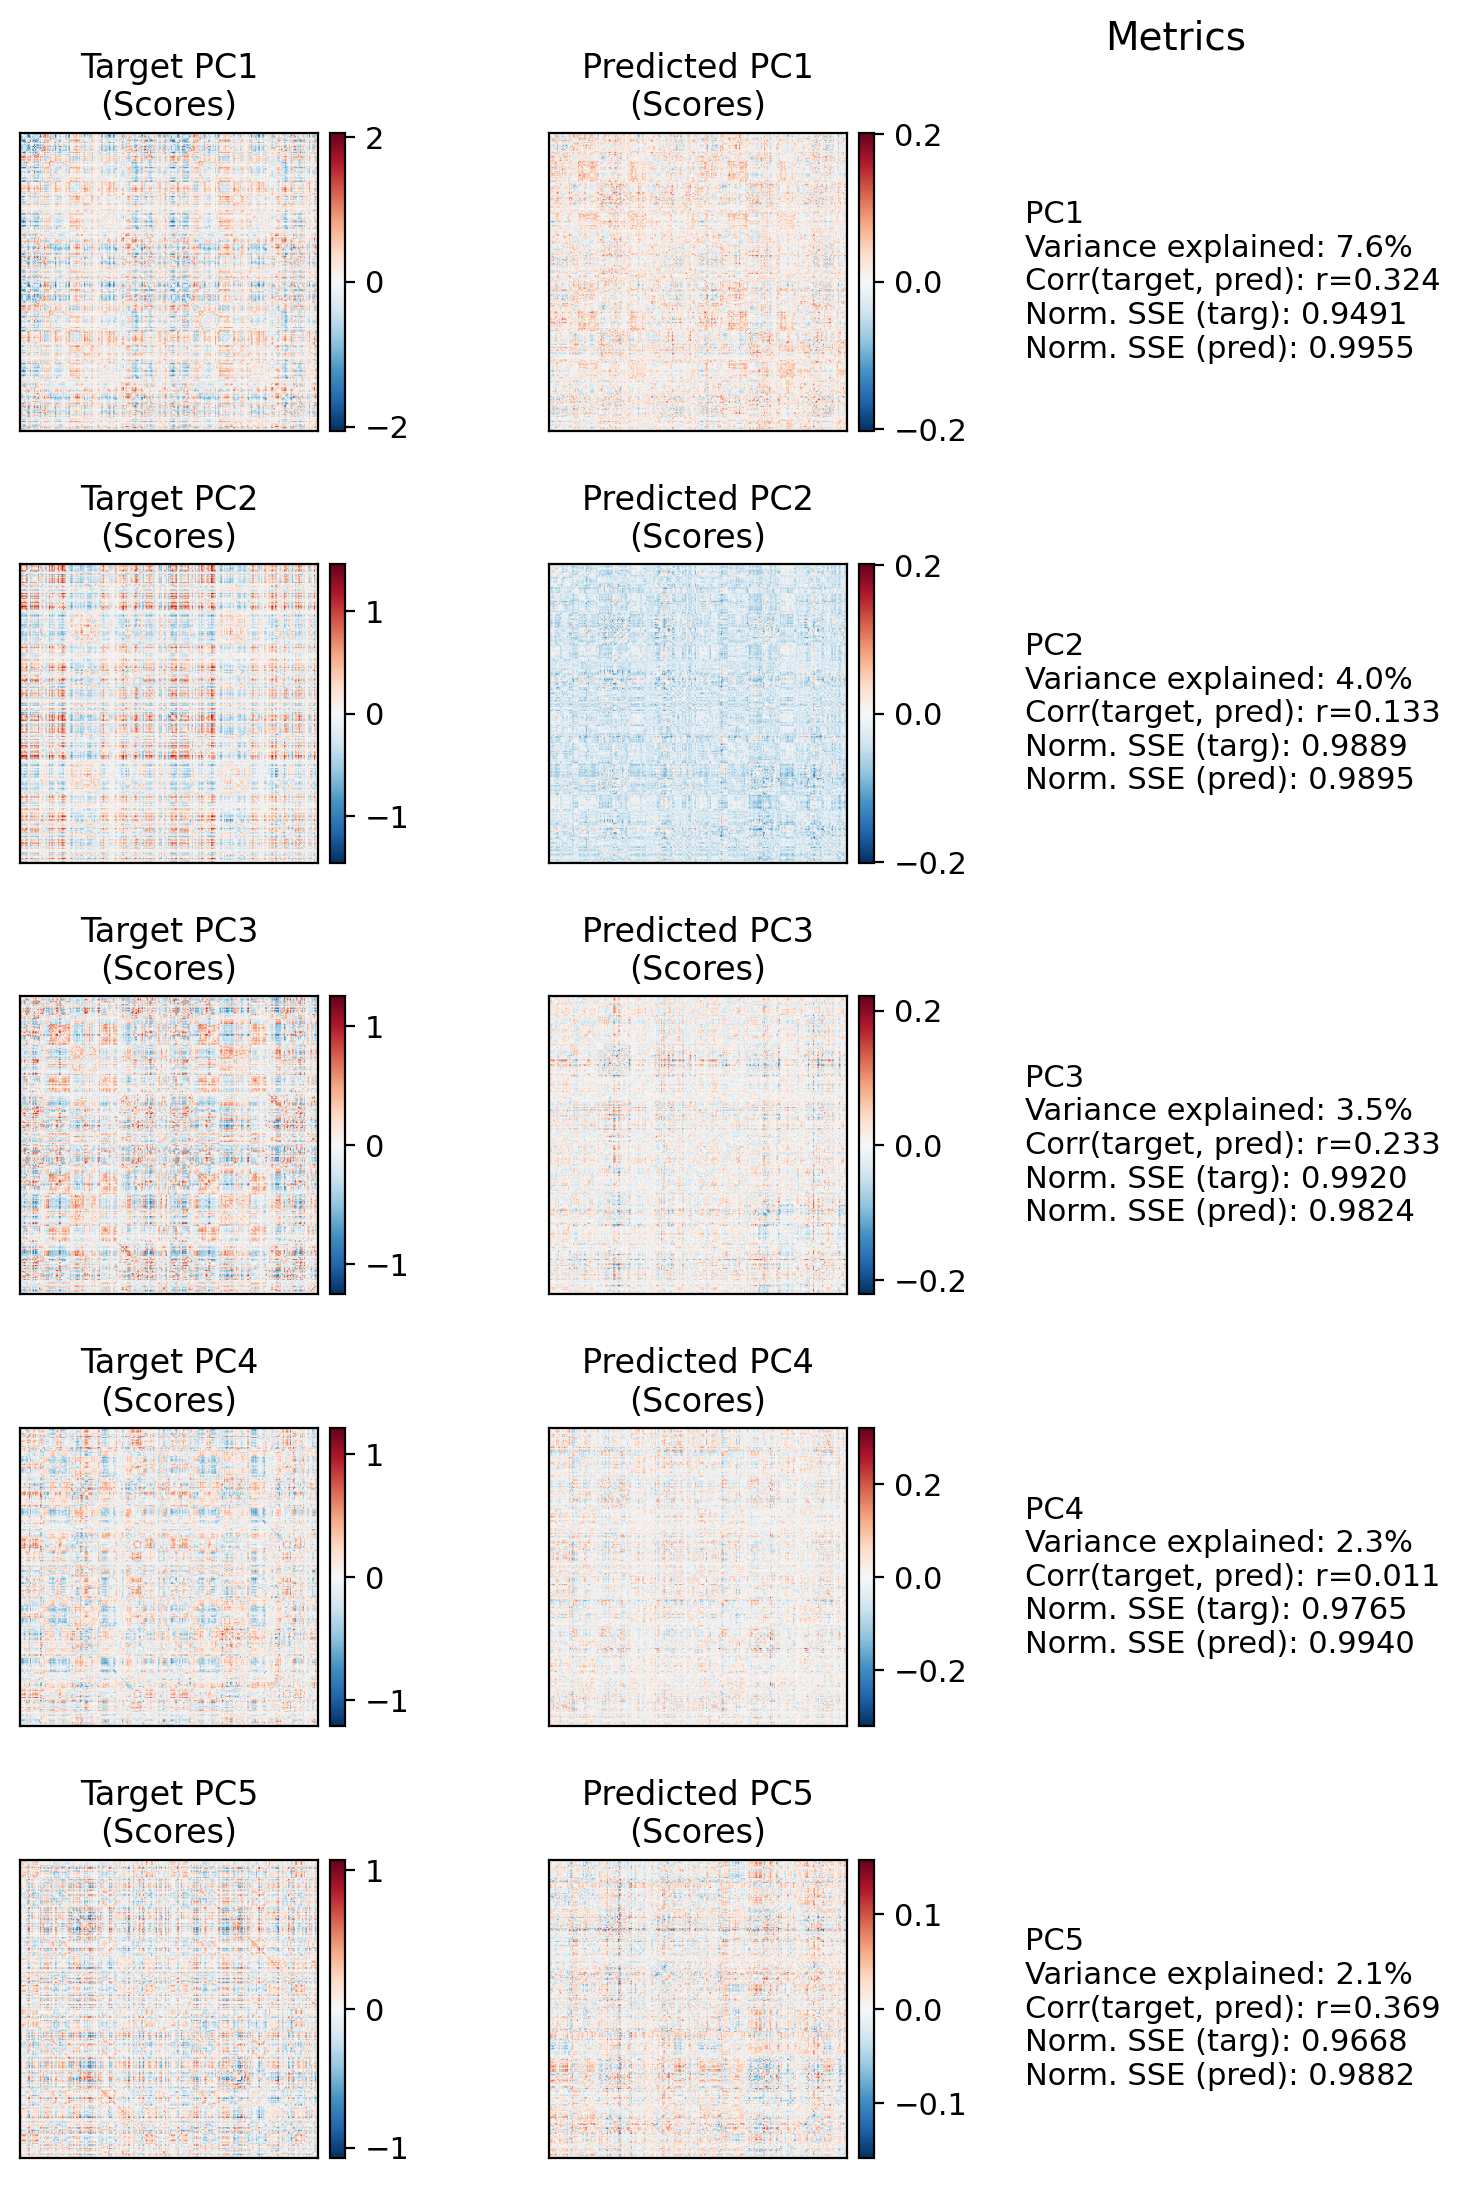

{'mse': np.float32(0.013563419),
 'r2': np.float32(-0.031434767),
 'pearson': np.float32(0.8359165),
 'demeaned_pearson': np.float32(0.08987455),
 'avg_rank': np.float64(0.765733070348455),
 'top1_acc': np.float64(0.08717948717948718)}

In [14]:
config_override = {
    "model": {
        "n_components_pca": 256,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 64,
        "attn_dim": 64,
        "value_dim": 64,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 64,
        "residual_mode": "linear_residual",
        "residual_gain_init": 1.0e-3,
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 1e-5,
    },
    "trainer": {
        "max_epochs": 200,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=True,
)

run_out["test_metrics"]["base_metrics"]


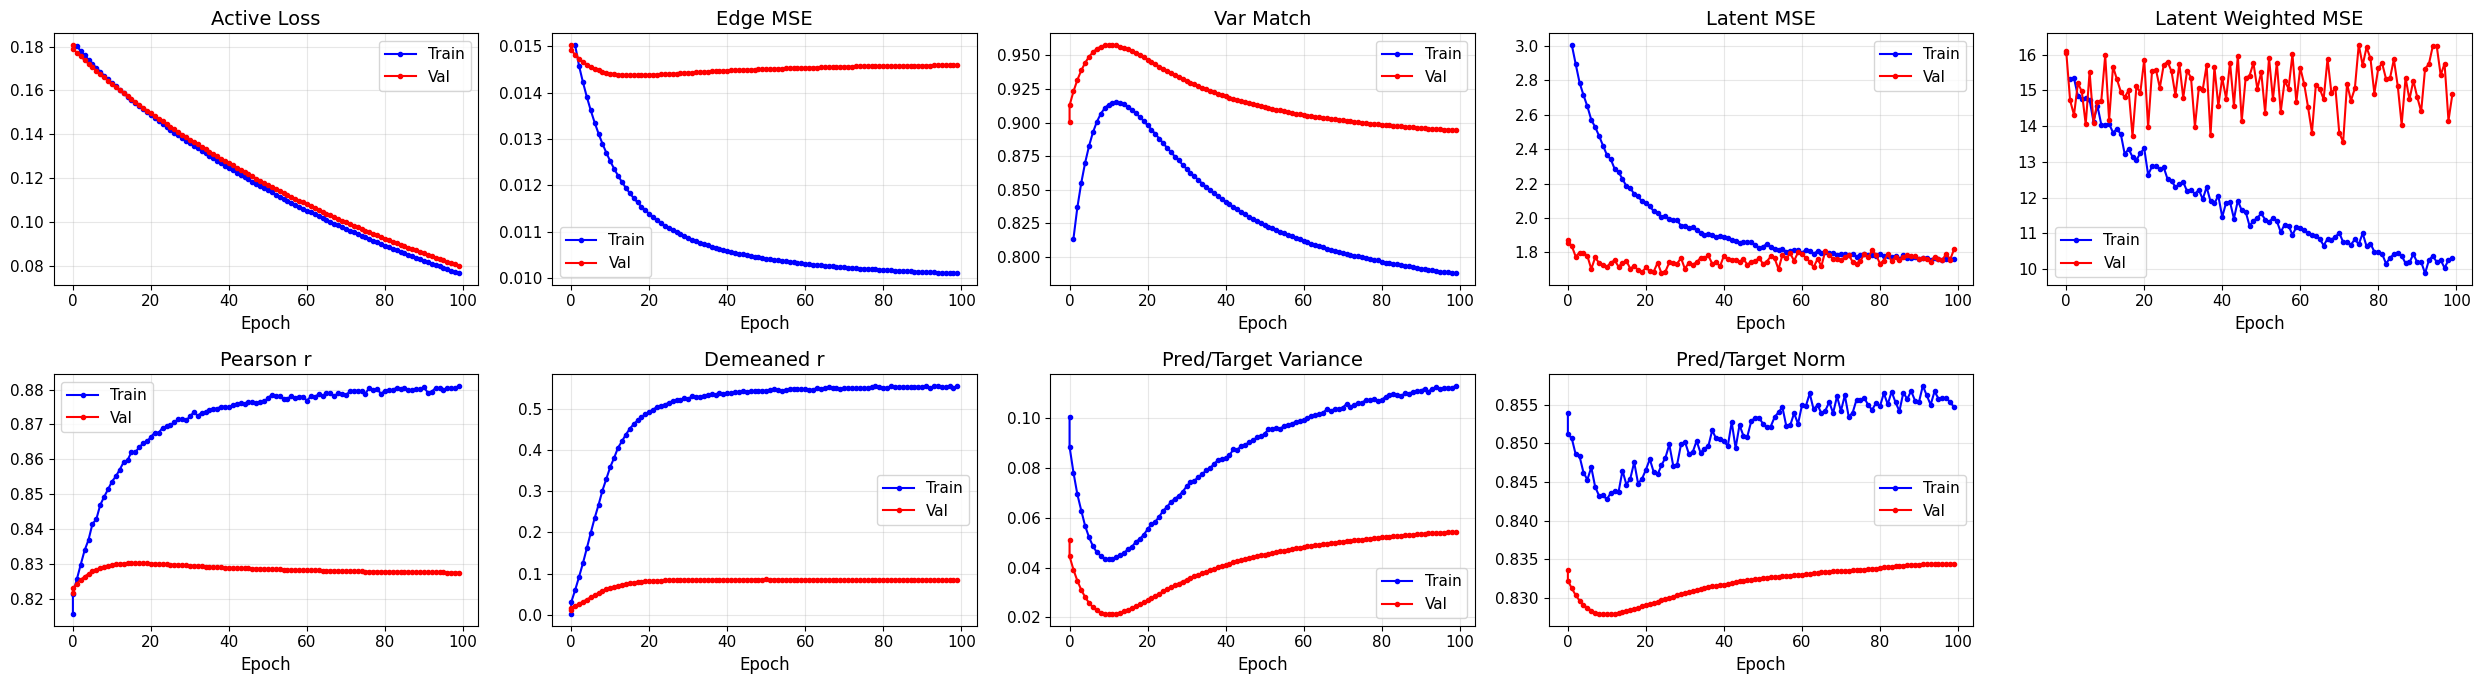

In [15]:
run_out["train_result"].plot(style="latent")

In [16]:
model_trained = run_out["model"]
model_trained.eval()

val_batch = next(iter(sim.val_loader))
x_val = get_model_input(val_batch)
y_val = val_batch["y"]

with torch.no_grad():
    inspect_ex = model_trained.inspect_attention_state(x_val[:1], y=y_val[:1], force_all_masked=True)
    inspect_mean = model_trained.inspect_attention_state(x_val[:16], y=y_val[:16], force_all_masked=True)

print("residual_gain:", float(model_trained.residual_gain.item()))


residual_gain: -0.0009930675150826573


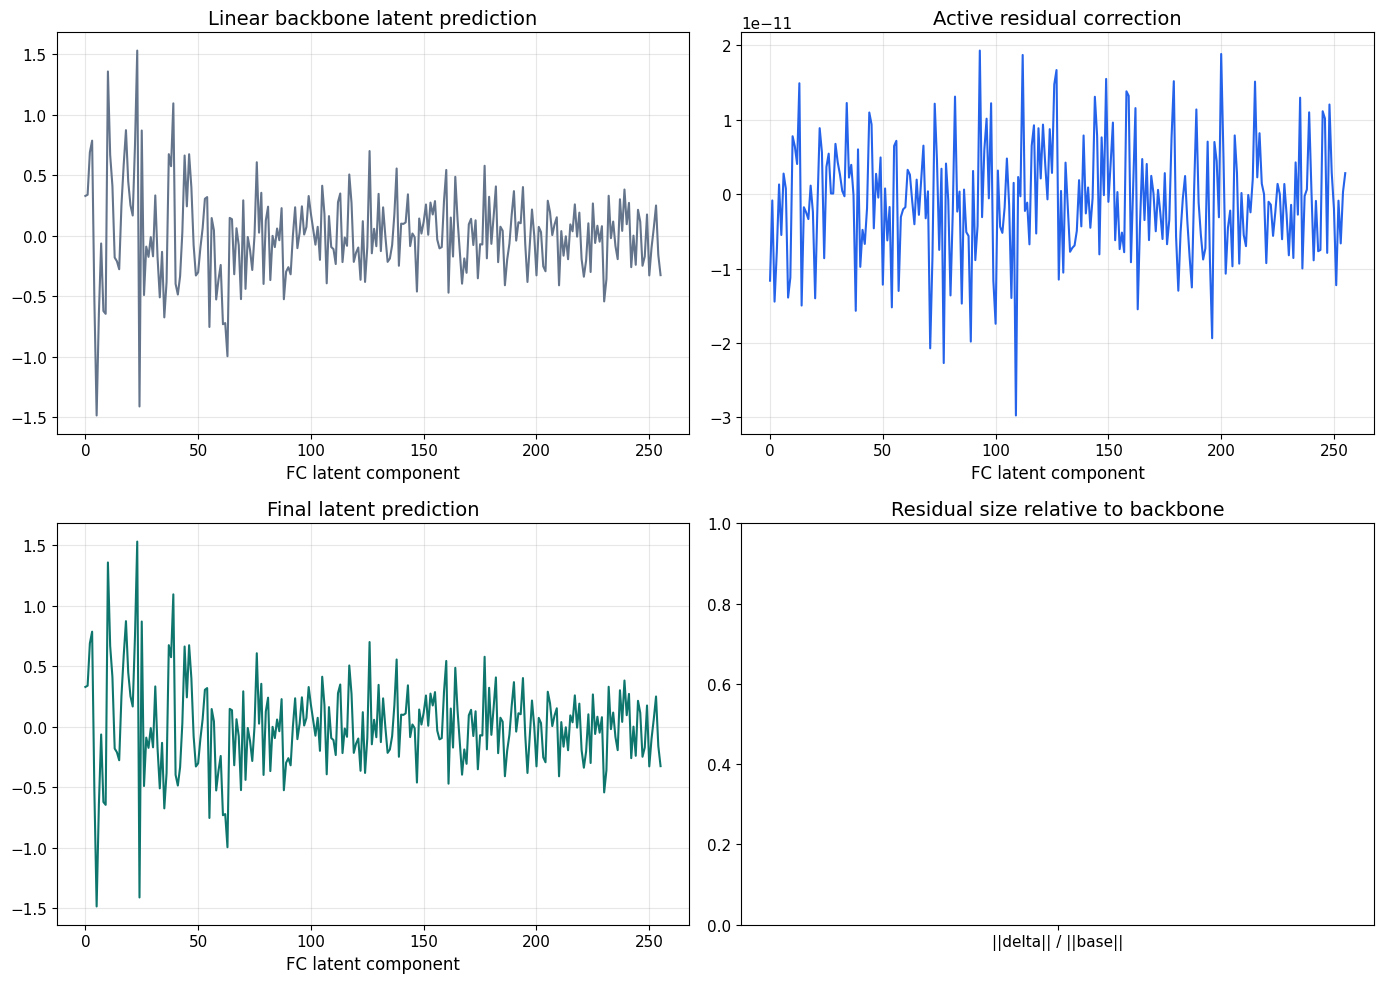

In [17]:
base_ex = inspect_ex["c_target_base"].detach().cpu().squeeze(0).numpy()
delta_ex = inspect_ex["c_target_delta"].detach().cpu().squeeze(0).numpy()
final_ex = inspect_ex["c_target_hat"].detach().cpu().squeeze(0).numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(base_ex, color="#64748b")
axes[0, 0].set_title("Linear backbone latent prediction")
axes[0, 0].set_xlabel("FC latent component")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(delta_ex, color="#2563eb")
axes[0, 1].set_title("Active residual correction")
axes[0, 1].set_xlabel("FC latent component")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(final_ex, color="#0f766e")
axes[1, 0].set_title("Final latent prediction")
axes[1, 0].set_xlabel("FC latent component")
axes[1, 0].grid(alpha=0.3)

ratio = np.linalg.norm(delta_ex) / max(np.linalg.norm(base_ex), 1e-8)
axes[1, 1].bar(["||delta|| / ||base||"], [ratio], color="#7c3aed")
axes[1, 1].set_title("Residual size relative to backbone")
axes[1, 1].set_ylim(0, max(1.0, ratio * 1.2))

plt.tight_layout()
plt.show()


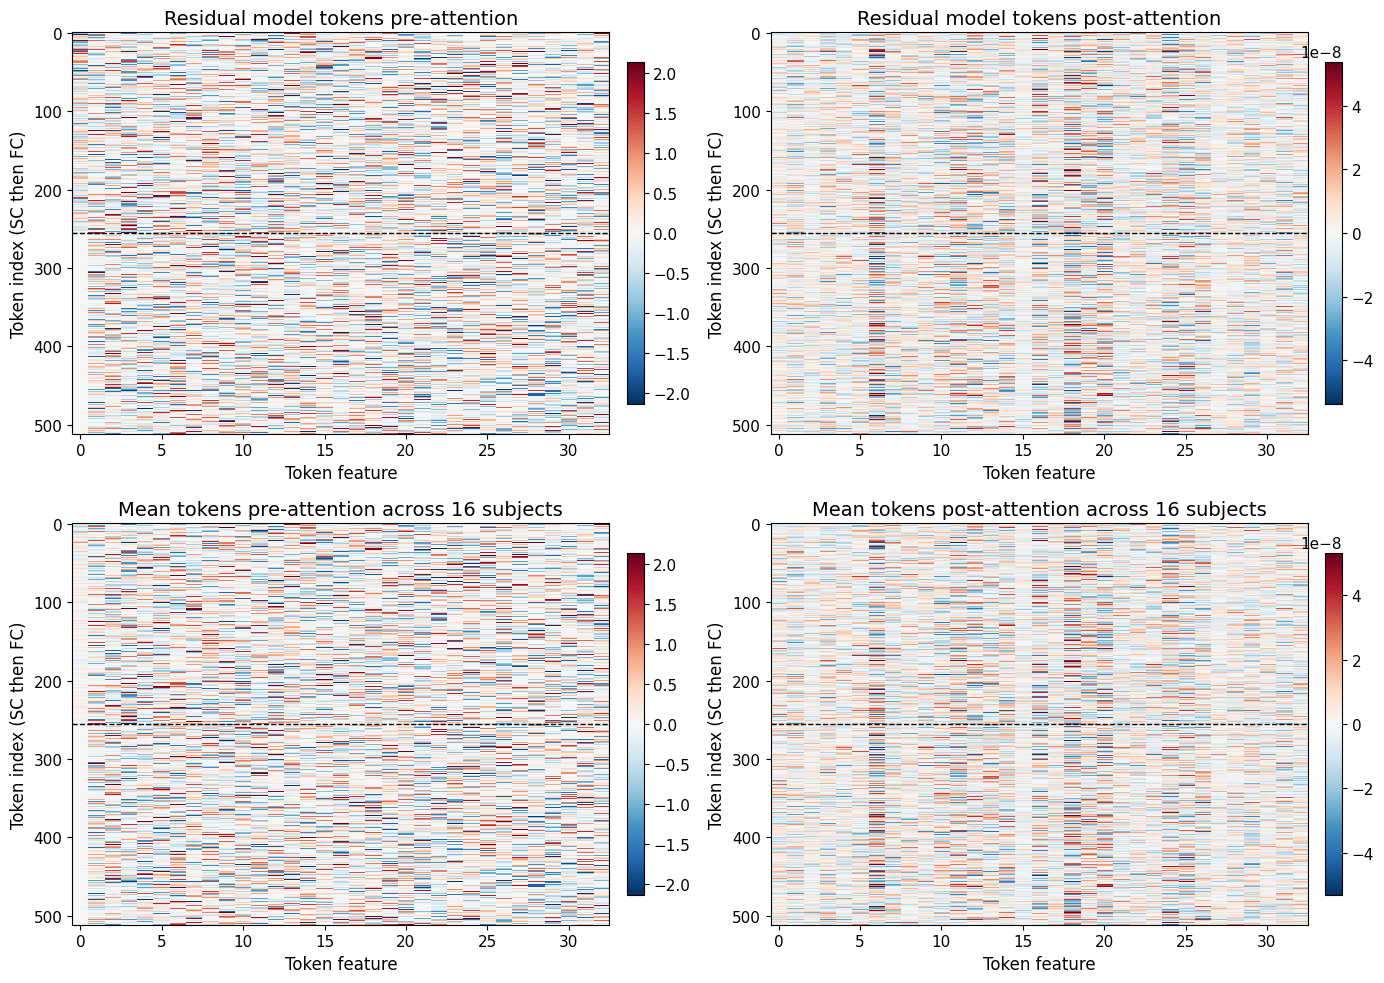

In [21]:
def show_tokens(title, tensor):
    arr = tensor.detach().cpu().squeeze(0).numpy()
    bound = np.quantile(np.abs(arr), 0.995) + 1e-8
    plt.imshow(
        arr,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-bound,
        vmax=bound,
        interpolation="nearest",
    )
    plt.title(title)
    plt.xlabel("Token feature")
    plt.ylabel("Token index (SC then FC)")
    plt.axhline(model_trained.n_components_pca - 0.5, color="k", linestyle="--", linewidth=1)
    plt.colorbar(fraction=0.03, pad=0.03)

fig = plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
show_tokens("Residual model tokens pre-attention", inspect_ex["tokens_pre"])
plt.subplot(2, 2, 2)
show_tokens("Residual model tokens post-attention", inspect_ex["tokens_post"])
plt.subplot(2, 2, 3)
show_tokens("Mean tokens pre-attention across 16 subjects", inspect_mean["tokens_pre"].mean(dim=0, keepdim=True))
plt.subplot(2, 2, 4)
show_tokens("Mean tokens post-attention across 16 subjects", inspect_mean["tokens_post"].mean(dim=0, keepdim=True))
plt.tight_layout()
plt.show()


## Math Summary

This notebook is the true hybrid model: a linear latent backbone plus an active residual correction path.
It uses `readout_type="scalar_slot"`, so the residual branch reads its prediction directly from the first feature channel of the FC token rows after attention.

Start from the source latent vector

$$
c_s \in \mathbb{R}^k.
$$

The linear backbone produces a base FC latent prediction

$$
c_{base} = W_{lin} c_s + b_{lin}.
$$

Separately, the model builds subject-specific SC and FC tokens:

$$
T^{pre}_{SC,i} = [c_{s,i}; e^{SC}_i], \qquad
T^{pre}_{FC,j} = [m_j; e^{FC}_j].
$$

Here $m_j$ is either the visible FC latent value for that subject or the learned mask value if that FC component is masked.
So the token plots in the notebook are the token matrices before and after this interaction step:

- `tokens_pre`: token features before token-token mixing
- `tokens_post`: token features after token-token mixing

Because this notebook uses identity attention, the interaction map is the raw score matrix

$$
A = \frac{QK^\top}{\sqrt{d_a}}, \qquad Q = T^{pre}W_Q, \quad K = T^{pre}W_K.
$$

The post-attention token matrix is

$$
T^{post} = AV,
$$

and because `scalar_slot` is used, the residual latent correction is the first feature channel of the FC token rows:

$$
\Delta c = T^{post}_{FC,:,0}.
$$

The final latent prediction is therefore

$$
\hat c_t = c_{base} + g\,\Delta c,
$$

where $g$ is the learned residual gain.

So the interpretation of the main plots is:

- `c_target_base`: what the linear backbone predicts on its own
- `c_target_delta`: the residual correction proposed by the attention path
- `c_target_hat`: the final sum of backbone plus residual correction

This notebook is useful when you want to see whether the attention branch is adding a small refinement or making a large correction on top of the linear backbone.


In [ ]:
artifact_dir = RESULTS_ROOT / "latent_masked_linear_residual_overview"
artifact_dir.mkdir(parents=True, exist_ok=True)
report_base = artifact_dir / "eval_test"

test_eval = run_out["evaluators"]["test"]
report_metrics = test_eval.analyze_results(
    verbose=False,
    filepath=str(report_base),
    output_format="md",
    model_name="LatentAttnMasked_linear_backbone_plus_residual",
)

print(f"Markdown report saved to: {report_base}.md")
report_metrics["base_metrics"]
